# ATLAS R3.0 / ISLES'26 training-set EDA

Native-space T1w MRI and ischemic stroke lesion masks.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

## 1. Set up the environment and libraries

In [2]:
import os
import re
import tarfile
import shutil
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage

In [3]:
ROOT = "D:/research/brain_vlm_xai"

In [4]:
TAR_PATH = ROOT + '/datasets/ISLES-26/raw/atlas3_training_raw.tar.gz'
DECRYPTED_PATH = ROOT + '/datasets/ISLES-26/raw/ATLAS_R3.0_raw.tar.gz'

EXTRACT_DIR_DRIVE = ROOT + '/datasets/ISLES-26/raw/ATLAS3_Training_Raw'


# LOCAL_DIR = "/content/atlas3_training_raw"
LOCAL_DIR = EXTRACT_DIR_DRIVE

### Decrypt the archive if needed

In [5]:
#!openssl aes-256-cbc -md sha256 -d -a -in "{TAR_PATH}" -out "{DECRYPTED_PATH}"

## 2. Locate or extract the dataset

In this local run, `LOCAL_DIR` points to `D:/research/brain_vlm_xai/datasets/ISLES-26/raw/ATLAS3_Training_Raw`. The archive extraction is skipped because this directory already exists. The commented Colab copy cells are not part of the active workflow.

In [6]:
if not os.path.exists(EXTRACT_DIR_DRIVE):
    os.makedirs(EXTRACT_DIR_DRIVE, exist_ok=True)
    with tarfile.open(DECRYPTED_PATH, 'r:gz') as tf:
        tf.extractall(EXTRACT_DIR_DRIVE)
    print("Extract to drive Drive:", EXTRACT_DIR_DRIVE)
else:
    print("Is Existed on Drive, cancel extraction:", EXTRACT_DIR_DRIVE)

Is Existed on Drive, cancel extraction: D:/research/brain_vlm_xai/datasets/ISLES-26/raw/ATLAS3_Training_Raw


In [7]:
# if not os.path.exists(LOCAL_DIR):
#     shutil.copytree(EXTRACT_DIR_DRIVE, LOCAL_DIR)
#     print("Da copy ve local:", LOCAL_DIR)
# else:
#     print("Da co ban local, bo qua copy:", LOCAL_DIR)

In [8]:
# import subprocess

# if not os.path.exists(LOCAL_DIR):
#     # -a: archive mode (giữ nguyên quyền, timestamps)
#     # -h: human-readable, -q: quiet (hoặc --info=progress2 để xem tiến trình)
#     cmd = f'rsync -ah "{EXTRACT_DIR_DRIVE}/" "{LOCAL_DIR}"'
#     subprocess.run(cmd, shell=True, check=True)
#     print("Da copy qua rsync:", LOCAL_DIR)
# else:
#     print("Da co ban local, bo qua:", LOCAL_DIR)

## 3. Inventory files and inspect one subject

The observed directory structure is `ATLAS3_Training_Raw/<R0XX>/sub-<r0XXsYYY>/ses-1/anat/`. Here, `R0XX` identifies the cohort/site, `sub-...` identifies a subject, `ses-1` is the session, and `anat` is the anatomical imaging directory. The next two cells count files and inspect the filenames and metadata for one subject.

In [9]:
all_files = [str(p) for p in Path(LOCAL_DIR).rglob("*") if p.is_file()]
print(f"total file: {len(all_files)}")

ext_count = defaultdict(int)
for f in all_files:
    ext_count["".join(Path(f).suffixes)] += 1
print("file structure:")
for ext, c in sorted(ext_count.items(), key=lambda x: -x[1]):
    print(f"  {ext or '(no ext)'}: {c}")

meta_files = sorted(f for f in all_files if f.endswith(".csv"))
nii_files = sorted(f for f in all_files if f.endswith((".nii.gz", ".nii")))
print(f"\nNum of .csv files (metadata, 1/subject): {len(meta_files)}")
print(f"Num of .nii.gz files (2/subject: T1w + mask): {len(nii_files)}")

total file: 4370
file structure:
  .nii.gz: 2906
  .csv: 1453
  (no ext): 11

Num of .csv files (metadata, 1/subject): 1453
Num of .nii.gz files (2/subject: T1w + mask): 2906


**Observation.** The inventory contains 4,370 files: 2,906 NIfTI images and 1,453 CSV files. These counts are consistent with one T1w image, one lesion mask, and one metadata file per subject, pending the subject-level matching check below. The 11 files without extensions are not classified here.

In [10]:
# Schema that: liet ke toan bo file cua 1 subject bat ky
sample_subject_dir = Path(meta_files[0]).parent
print("Noi dung thu muc 1 subject mau:")
for f in sorted(sample_subject_dir.iterdir()):
    print(" ", f.name)

print("\nNoi dung metadata.csv cua subject nay:")
display(pd.read_csv(meta_files[0]))

Noi dung thu muc 1 subject mau:
  sub-r001s001_ses-1_metadata.csv
  sub-r001s001_ses-1_space-orig_desc-brain_T1w.nii.gz
  sub-r001s001_ses-1_space-orig_label-lesion_desc-T1lesion_mask.nii.gz

Noi dung metadata.csv cua subject nay:


,SESSION_ID,ATLAS2_DATASET,DAYS_POST_STROKE,CHRONICITY,SITE
0,sub-r001s001_ses-1,Training,471.0,NaN,R001


**Observation.** The example subject has three files: a T1w image, a lesion mask, and metadata. Its metadata contains `SESSION_ID`, `ATLAS2_DATASET`, `DAYS_POST_STROKE`, `CHRONICITY`, and `SITE`. `CHRONICITY` is missing for this subject; inspect the full table before using that field to group cases.

## 4. Match T1w images and lesion masks by subject

The code identifies masks from keywords in the filenames rather than assuming fixed `_T1w` and `_mask` suffixes, which may differ across releases.

In [11]:
def subject_id(f):
    m = re.search(r"(sub-[a-z0-9]+)", f, re.I)
    return m.group(1) if m else Path(f).stem

mask_like = [f for f in nii_files if re.search(r"mask|lesion|label", f, re.I)]
img_like = [f for f in nii_files if f not in mask_like]

img_by_sub = {subject_id(f): f for f in img_like}
mask_by_sub = {subject_id(f): f for f in mask_like}
meta_by_sub = {subject_id(f): f for f in meta_files}

subs = sorted(set(img_by_sub) & set(mask_by_sub))
print(f"Subject have full image + mask: {len(subs)} / {len(img_by_sub)}")
print(f"Subject is missing mask: {sorted(set(img_by_sub) - set(mask_by_sub))[:5]}")

Subject have full image + mask: 1453 / 1453
Subject is missing mask: []


**Observation.** All 1,453 subjects with a T1w image also have a matched mask; the missing-mask list is empty. This checks file presence by subject ID. It does not establish that each image and mask share the same dimensions or affine, or that the lesion is positioned correctly. The geometry and visual QC sections below help assess those points.

## 5. Combine metadata and inspect missing values

The joined table has 1,451 rows even though 1,453 subject CSV files exist. Two SOOP metadata files (`sub-soop1701` and `sub-soop0910`) contain headers but no data rows. Among the remaining rows, `CHRONICITY` is 79.6% missing and `DAYS_POST_STROKE` is 23.4% missing. The clinical meaning of `CHRONICITY = 1` needs the dataset codebook before interpretation.

In [12]:
meta_df = pd.concat(
    [pd.read_csv(meta_by_sub[s]).assign(subject=s) for s in subs],
    ignore_index=True,
)
print(meta_df.shape)
print(meta_df.columns.tolist())
meta_df.head()

(1451, 6)
['SESSION_ID', 'ATLAS2_DATASET', 'DAYS_POST_STROKE', 'CHRONICITY', 'SITE', 'subject']


C:\Users\HUY\AppData\Local\Temp\ipykernel_4172\399706329.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  meta_df = pd.concat(


,SESSION_ID,ATLAS2_DATASET,DAYS_POST_STROKE,CHRONICITY,SITE,subject
0,sub-r001s001_ses-1,Training,471.0,NaN,R001,sub-r001s001
1,sub-r001s002_ses-1,Training,669.0,NaN,R001,sub-r001s002
2,sub-r001s003_ses-1,Training,709.0,NaN,R001,sub-r001s003
3,sub-r001s004_ses-1,Training,871.0,NaN,R001,sub-r001s004
4,sub-r001s005_ses-1,Training,1917.0,NaN,R001,sub-r001s005


In [13]:
for col in meta_df.columns:
    if meta_df[col].nunique() < 30:
        print(f"--- {col} ---")
        print(meta_df[col].value_counts(dropna=False))
        print()
print("Missing values on cols:")
print(meta_df.isna().mean().sort_values(ascending=False))

--- ATLAS2_DATASET ---
ATLAS2_DATASET
Training           653
ATLAS3             496
Testing            299
Training_ATLAS2      2
Testing_ATLAS2       1
Name: count, dtype: int64

--- CHRONICITY ---
CHRONICITY
NaN    1155
1.0     296
Name: count, dtype: int64

Missing values on cols:
CHRONICITY          0.796003
DAYS_POST_STROKE    0.233632
ATLAS2_DATASET      0.000000
SESSION_ID          0.000000
SITE                0.000000
subject             0.000000
dtype: float64


## 6. Inspect image geometry: shape, voxel spacing, and orientation

In this unseeded 200-subject sample, 127 scans are RAS and 73 LAS. Voxel sizes and image shapes vary widely (through-plane spacing 0.25–6.00 mm), so orientation and resampling should be checked before 3D modeling. These are sample results, not full-cohort frequencies.

In [14]:
SAMPLE_N = 200  # tang len len(subs) neu muon chay full 1453 case (cham hon)
sample_subs = random.sample(subs, min(SAMPLE_N, len(subs)))

geo_rows = []
for s in sample_subs:
    img = nib.load(img_by_sub[s])
    zooms = img.header.get_zooms()
    geo_rows.append({
        "subject": s,
        "dim_x": img.shape[0], "dim_y": img.shape[1], "dim_z": img.shape[2],
        "spacing_x": zooms[0], "spacing_y": zooms[1], "spacing_z": zooms[2],
        "orientation": "".join(nib.aff2axcodes(img.affine)),
        "dtype": str(img.get_data_dtype()),
    })
geo_df = pd.DataFrame(geo_rows)

print("Orientation:")
print(geo_df["orientation"].value_counts())
print("\nSpacing (mm):")
print(geo_df[["spacing_x", "spacing_y", "spacing_z"]].describe())
print("\nShape (voxel):")
print(geo_df[["dim_x", "dim_y", "dim_z"]].describe())

Orientation:
orientation
RAS    127
LAS     73
Name: count, dtype: int64

Spacing (mm):
        spacing_x   spacing_y   spacing_z
count  200.000000  200.000000  200.000000
mean     0.964949    0.963273    0.996386
std      0.166378    0.323206    0.552584
min      0.479167    0.250749    0.250749
25%      0.999934    0.976562    0.976562
50%      1.000000    1.000000    1.000000
75%      1.000000    1.000000    1.000000
max      1.500000    3.000000    6.000001

Shape (voxel):
            dim_x       dim_y        dim_z
count  200.000000   200.00000   200.000000
mean   201.315000   281.20500   272.285000
std     59.801815   110.39328   118.055492
min     96.000000   120.00000    24.000000
25%    176.000000   230.75000   224.000000
50%    180.000000   256.00000   256.000000
75%    208.000000   256.00000   256.000000
max    480.000000  1008.00000  1008.000000


## 7. Inspect T1w intensity distributions

The 30-subject sample shows substantial between-scan variation in positive-voxel intensities: median per-scan mean intensity is about 344, while the largest observed per-scan mean is about 3,491. MRI has no fixed CT-like HU scale; this supports evaluating per-image clipping and normalization. The zero fraction includes background and should not be read as missing-image fraction.

In [15]:
int_rows = []
for s in random.sample(sample_subs, min(30, len(sample_subs))):
    vol = nib.load(img_by_sub[s]).get_fdata()
    brain = vol[vol > 0]  # da skull-stripped -> nen la 0
    int_rows.append({
        "subject": s, "min": brain.min(), "max": brain.max(),
        "mean": brain.mean(), "std": brain.std(),
        "p1": np.percentile(brain, 1), "p99": np.percentile(brain, 99),
        "pct_zero": float((vol == 0).mean()),
    })
int_df = pd.DataFrame(int_rows)
int_df.describe()

,min,max,mean,std,p1,p99,pct_zero
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,4.685899,2266.541149,705.437626,268.862243,132.797141,1176.769203,0.851896
std,8.719905,2640.403230,832.801532,289.655057,197.107911,1314.006771,0.043956
min,0.975662,315.000015,107.800412,47.811589,6.001236,197.997950,0.702300
25%,0.999828,711.750019,217.456368,84.862486,29.996640,357.499805,0.846567
50%,1.003120,1006.000030,343.964839,152.139871,60.501198,578.502412,0.863837
75%,4.081401,2452.298884,795.267281,328.900237,140.154287,1427.849048,0.876992
max,40.950883,10402.000455,3490.649797,1244.077449,903.935189,5632.016207,0.900328


## 8. Inspect lesion masks: volume and connected components

All 200 sampled masks are non-empty. Median lesion volume is 5,101.5 mm³ (about 5.1 mL), with a wide 12–289,688 mm³ range. A NIfTI warning reports non-positive `pixdim` being converted to absolute values; inspect affected headers and image–mask alignment before relying on physical-volume estimates. The sample is unseeded and is not a full-cohort estimate.

pixdim[1,2,3] should be positive; setting to abs of pixdim values


Ti le mask rong (khong lesion): 0.00%
count       200.000000
mean      28799.361781
std       52074.955057
min          12.000000
25%        1117.750000
50%        5101.500000
75%       31435.110078
max      289688.000000
Name: lesion_volume_mm3, dtype: float64


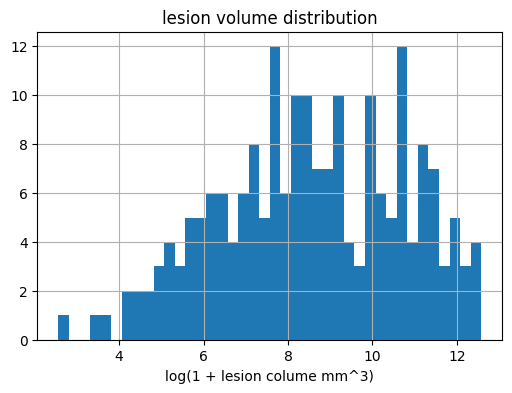

In [16]:
les_rows = []
for s in sample_subs:
    m = nib.load(mask_by_sub[s])
    arr = np.asarray(m.dataobj) > 0
    voxel_mm3 = float(np.prod(m.header.get_zooms()))
    n_vox = int(arr.sum())
    _, n_comp = ndimage.label(arr)
    les_rows.append({
        "subject": s, "lesion_present": n_vox > 0,
        "lesion_voxels": n_vox, "lesion_volume_mm3": n_vox * voxel_mm3,
        "n_components": n_comp,
    })
les_df = pd.DataFrame(les_rows)

print(f"Ti le mask rong (khong lesion): {(~les_df['lesion_present']).mean():.2%}")
print(les_df["lesion_volume_mm3"].describe())

plt.figure(figsize=(6, 4))
les_df.loc[les_df.lesion_present, "lesion_volume_mm3"].apply(np.log1p).hist(bins=40)
plt.xlabel("log(1 + lesion colume mm^3)")
plt.title("lesion volume distribution")
plt.show()

## 9. Visually inspect T1w images and masks on the middle slice

The saved 12-subject overlay gives a qualitative alignment check. A lesion outside the middle slice may not appear in this view, so this figure does not validate all image–mask pairs.

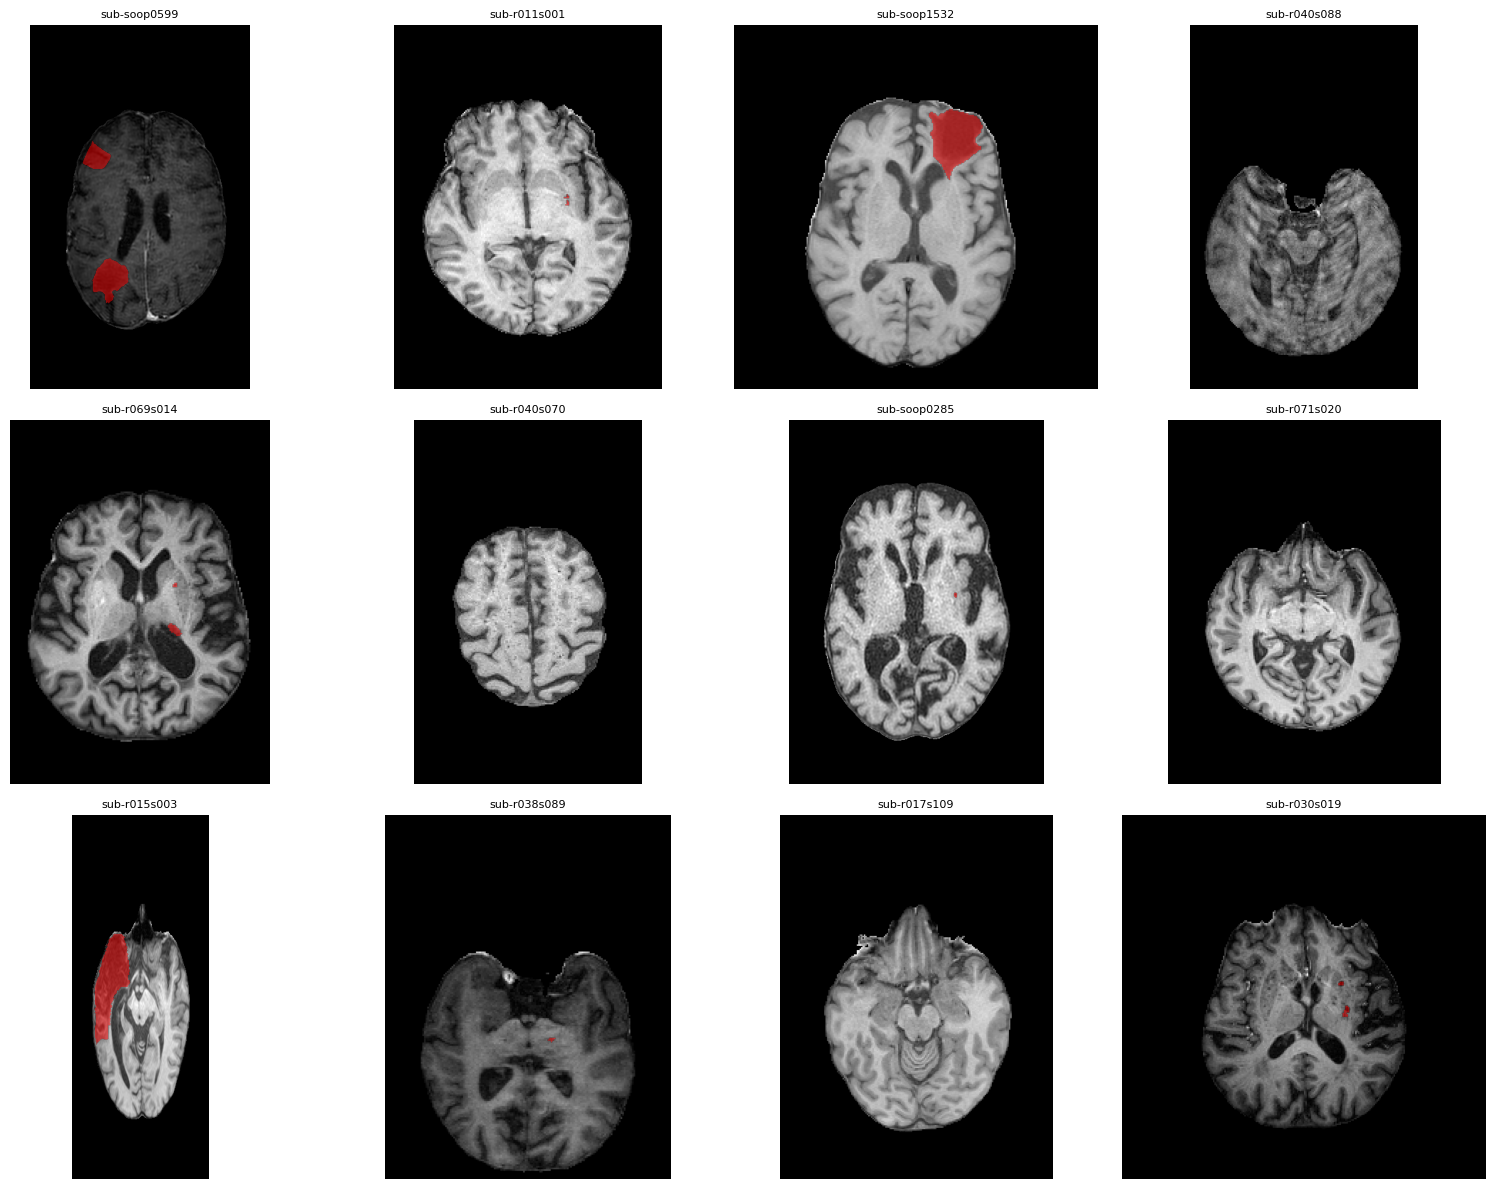

In [17]:
qc_subs = random.sample(sample_subs, 12)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, s in zip(axes.ravel(), qc_subs):
    vol = nib.load(img_by_sub[s]).get_fdata()
    mask = nib.load(mask_by_sub[s]).get_fdata()
    z = vol.shape[2] // 2
    ax.imshow(vol[:, :, z].T, cmap="gray", origin="lower")
    ax.imshow(np.ma.masked_where(mask[:, :, z].T == 0, mask[:, :, z].T),
               cmap="autumn", alpha=0.5, origin="lower")
    ax.set_title(s, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()